In [1]:
import os
from pathlib import Path
import cortex as cx
import numpy as np
import nibabel as nib
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rc
from matplotlib import font_manager
from prf_expect.utils import io
from prf_expect.utils.viz import desaturate_palette, sample_cmap, cm_to_inch

In [2]:
cwd = os.getcwd()
analysis_result_dir = Path(cwd).parent / "data"
figure_result_dir = Path(cwd).parent / "figures"

In [3]:
r2_thre = 0.3

In [4]:
font_dirs = [Path(cwd).parent.parent.parent / "arial"]
font_files = font_manager.findSystemFonts(fontpaths=font_dirs)
for font_file in font_files:
    font_manager.fontManager.addfont(font_file)

rc('pdf', fonttype=42, use14corefonts=False)
rc('axes', linewidth=0.5)
rc('font',**{'family':'Arial'})
rc('text', usetex=False)
rc('xtick', labelsize=6)
rc('ytick', labelsize=6)
rc('axes', labelsize=6)
rc('legend', fontsize=6)

plt.rcParams['xtick.major.width'] = 0.5
plt.rcParams['ytick.major.width'] = 0.5
plt.rcParams['xtick.major.size'] = 2
plt.rcParams['ytick.major.size'] = 2
plt.rcParams['xtick.minor.width'] = 0.5
plt.rcParams['ytick.minor.width'] = 0.5
plt.rcParams['xtick.minor.size'] = 1
plt.rcParams['ytick.minor.size'] = 1


In [5]:
ROIs_list_long = ('V1', 'V2', 'V3', 'V3A', 'V3B', 'V4', 'LO1', 'LO2', 'VO1', 
        'VO2', 'hMT', 'MST', 'IPS0', 'IPS1', 'IPS2', 'IPS3', 'IPS4', 'IPS5')
roi_verts = cx.get_roi_verts('fsaverage', ROIs_list_long)
V1 = roi_verts['V1']
vis_verts = np.array([], dtype=int)
for roi in roi_verts:
    vis_verts = np.concatenate((vis_verts, roi_verts[roi]))

In [6]:
# Define paths and data exp parameters
settings = io.load_settings()
data_dir = Path(settings['general']['data_dir'], "data")
print(f"data dir: {data_dir}")
tasks = settings["design"]["tasks"]
space = settings["mri"]["space"]
subjects = settings["general"]["subject_list"]

Loading settings from /tank/nwa201/projects/pRF_expect/code/pRF_expect_analysis/prf_expect/settings.yml
data dir: /tank/shared/2023/prfexpect/data


In [7]:
# check hrf for each region
rsq_list = []
rsq_list_2 = []
rsq_nanmask_list = []
hrf_deriv_list = []
hrf_disp_list = []

for subject in subjects:
    tsv_name = Path.joinpath(data_dir, 
                            "derivatives", 
                            "prf_data", 
                            subject, 
                            "ses-1", 
                            "prf_fits", 
                            "prf_params", 
                            f"{subject}_ses-1_final-fit_space-{space}_model-norm_stage-iter_desc-prf_params.tsv")
    data = pd.read_csv( 
            tsv_name,
            sep="\t",
            header=0,
        )
    mask = data["r2"] >= r2_thre
    mask_broadcasted = np.tile(mask, (data.shape[1], 1)).T
    params = data.where(mask_broadcasted)
    # print column names
    params_np = params.to_numpy()
    verts_nr = params["r2"].shape[0]
    
    sub_vis_rsq = np.zeros(verts_nr)
    sub_vis_rsq[:] = np.nan
    sub_vis_rsq = params["r2"]

    sub_vis_hrf_deriv = np.zeros(verts_nr)
    sub_vis_hrf_deriv[:] = np.nan
    sub_vis_hrf_deriv = params["hrf_deriv"]

    sub_vis_hrf_disp = np.zeros(verts_nr)
    sub_vis_hrf_disp[:] = np.nan
    sub_vis_hrf_disp = params["hrf_disp"]
    
    sub_vis_rsq_2 = sub_vis_rsq.copy()
    sub_vis_hrf_deriv = np.nan_to_num(sub_vis_hrf_deriv, copy=True, nan=0.0)
    sub_vis_hrf_disp = np.nan_to_num(sub_vis_hrf_disp, copy=True, nan=0.0)
 
    rsq_list.append(sub_vis_rsq)
    rsq_list_2.append(sub_vis_rsq_2)
    hrf_deriv_list.append(sub_vis_hrf_deriv)
    hrf_disp_list.append(sub_vis_hrf_disp)

    viz_data_rsq_nanmask = ~np.isnan(sub_vis_rsq)
    rsq_nanmask_list.append(viz_data_rsq_nanmask)


rsq_list = np.array(rsq_list)
rsq_list_2 = np.array(rsq_list_2)
rsq_nanmask_list = np.array(rsq_nanmask_list)

avg_nanmask = np.any(rsq_nanmask_list, axis=0)
avg_rsq = np.nanmean(rsq_list, axis=0)
avg_rsq = np.nan_to_num(avg_rsq, copy=True, nan=0.0)
avg_rsq_2 = np.nanmean(rsq_list_2, axis=0)
avg_rsq_2 = np.nan_to_num(avg_rsq_2, copy=True, nan=0.0)
rsq_list_nonan = np.nan_to_num(rsq_list, copy=True, nan=1e-6)
rsq_list_2_nonan = np.nan_to_num(rsq_list_2, copy=True, nan=1e-6)

hrf_deriv_list = np.array(hrf_deriv_list)
hrf_disp_list = np.array(hrf_disp_list)


/tmp/ipykernel_2184509/871486141.py:59: RuntimeWarning: Mean of empty slice
  avg_rsq = np.nanmean(rsq_list, axis=0)
/tmp/ipykernel_2184509/871486141.py:61: RuntimeWarning: Mean of empty slice
  avg_rsq_2 = np.nanmean(rsq_list_2, axis=0)


In [8]:
# from prfpy
from prfpy.timecourse import tdm_hrf
from nilearn.glm.first_level.hemodynamic_models import spm_hrf, spm_time_derivative, spm_dispersion_derivative

def create_hrf(hrf_params, hrf_basis="spm", normalize_hrf=True, t_r=0.1):
        """
        
        construct single or multiple HRFs        

        Parameters
        ----------
        hrf_params : TYPE, optional
            DESCRIPTION. The default is [1.0, 1.0, 0.0].

        Returns
        -------
        hrf : ndarray
            the hrf.

        """
        if hrf_basis.lower() == 'spm':
            hrf = np.array(
                [
                    np.ones_like(hrf_params[1], dtype='float32')*hrf_params[0] *
                    spm_hrf(
                        tr=t_r,
                        oversampling=1,
                        time_length=40)[...,np.newaxis],
                    hrf_params[1] *
                    spm_time_derivative(
                        tr=t_r,
                        oversampling=1,
                        time_length=40)[...,np.newaxis],
                    hrf_params[2] *
                    spm_dispersion_derivative(
                        tr=t_r,
                        oversampling=1,
                        time_length=40)[...,np.newaxis]],
                        dtype='float32').sum(
                axis=0).T
        elif hrf_basis.lower() == 'tdm':

            hrf =  tdm_hrf(hrf_params[1],
                        tr=t_r,
                        time_length=40)                  
            
        else:
            print("Unknown HRF basis. use spm or tdm. defaulting to spm")                    
            hrf = np.array(
                [
                    np.ones_like(hrf_params[1], dtype='float32')*hrf_params[0] *
                    spm_hrf(
                        tr=t_r,
                        oversampling=1,
                        time_length=40)[...,np.newaxis],
                    hrf_params[1] *
                    spm_time_derivative(
                        tr=t_r,
                        oversampling=1,
                        time_length=40)[...,np.newaxis],
                    hrf_params[2] *
                    spm_dispersion_derivative(
                        tr=t_r,
                        oversampling=1,
                        time_length=40)[...,np.newaxis]],
                        dtype='float32').sum(
                axis=0).T
            
            
        if normalize_hrf:
            for i in range(hrf.shape[0]):
                hrf[i] /= np.max(hrf[i])
           

        return hrf

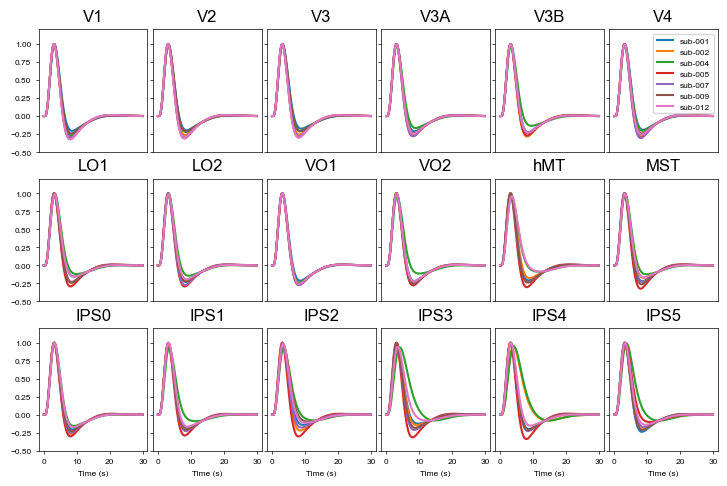

In [12]:
# for voxel\s whose rsq>rsq_thre in each region, plot hrf with the params
fig, axes = plt.subplots(3, 6, figsize=cm_to_inch(18, 12))
axes = axes.flatten()

t_r = 0.1
time_points = np.arange(0, 30, t_r) # Assuming 40s length as in create_hrf

# Use a qualitative colormap for distinguishable subjects
# 'tab10' is good for up to 10 categories
colors = plt.cm.tab10(np.linspace(0, 1, 10))

# For each region, plot a separate line for each subject (averaged across valid voxels)
for i, roi in enumerate(ROIs_list_long):
    if roi not in roi_verts:
        continue
        
    roi_indices = roi_verts[roi]
    ax = axes[i]
    
    # Iterate over subjects
    for s_idx, subject in enumerate(subjects):
        # Extract data for this subject and this ROI
        sub_roi_rsq = rsq_list[s_idx, roi_indices]
        sub_roi_deriv = hrf_deriv_list[s_idx, roi_indices]
        sub_roi_disp = hrf_disp_list[s_idx, roi_indices]
        
        # Filter for valid voxels
        valid_mask = (sub_roi_rsq > r2_thre) & (~np.isnan(sub_roi_rsq))
        
        if np.sum(valid_mask) == 0:
            continue
            
        valid_derivs = sub_roi_deriv[valid_mask]
        valid_disps = sub_roi_disp[valid_mask]
        valid_rsq = sub_roi_rsq[valid_mask]
        
        # Generate HRFs for valid voxels. 
        # Note: create_hrf can verify inputs. Let's pass array to vectorize if possible, 
        # or loop if create_hrf expects scalar params.
        # Based on previous cell, create_hrf seems to handle arrays if structure is [1.0, array, array]
        
        # We want the mean HRF for this subject in this ROI.
        # We can compute mean parameters and generate one HRF, or generate all and average.
        # Generating all is safer for non-linearity.
        
        subj_hrfs = create_hrf([1.0, valid_derivs, valid_disps], t_r=t_r)
        
        # Check shape. create_hrf returns (time, N) or (N, time)?
        # If input was arrays of shape (N,), output seems to be (time, N) based on .T logic in create_hrf?
        # Let's verify: In create_hrf: ..._hrf(...)[...,np.newaxis] -> (40, 1) broadcast with (N,) -> (40, N)
        # .sum(axis=0) -> (40, N). .T -> (N, 40).
        # Wait, inside create_hrf:
        # basis is (40, 1). params is (N,). basis * params -> (40, N).
        # stacked is (3, 40, N). sum(axis=0) -> (40, N). .T -> (N, 40).
        # So shape is (N_voxels, Time_points).
        
        # We need average across voxels
        mean_subj_hrf = np.average(subj_hrfs, axis=0, weights=valid_rsq)
        
        # Use color from the colormap corresponding to subject index
        color = colors[s_idx % len(colors)]
        ax.plot(time_points, mean_subj_hrf[:len(time_points)], label=subject, color=color)

    ax.set_title(f"{roi}")
    ax.set_ylim(-0.5, 1.2)
    
    # Remove x-axis labels for scatter plots in the first two rows (indices 0-11)
    # Only show x-label for the last row (indices 12-17)
    if i >= 12:
        ax.set_xlabel("Time (s)")
    else:
        ax.set_xticklabels([])
        ax.set_xticks([])


    # Remove y-axis labels for columns other than the first one (index 0)
    if i % 6 != 0:
        ax.set_yticklabels([])
    
    # Legend in the top right subplot (index 5)
    if i == 5:
        ax.legend(fontsize=6)

plt.tight_layout(pad=0.2, w_pad=0.2, h_pad=0.2)
plt.show()
figure_result_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(figure_result_dir / f"group_analysis-pRF_space-fsaverage_desc-prf_hrf.pdf", dpi=600, bbox_inches='tight')